<h1><center> PRÀCTICA 1 </center></h1>
<h1><center> MÈTODE DE RUNGE-KUTTA-FEHLBERG </center></h1>

### David Ramonell Pujol

### INTRODUCCIÓ
Treballarem en aquesta pràctica la implementació del mètode Runge-Kutta, amb el pas de variable independent adaptatiu proposat per Fehlberg (RKF). Aquest mètode de 4/5 ordre ens permet resoldre de manera eficient i precisa equacions diferencials ordinàries (EDOs).

### TASCA A)
Escriure un programa que, donada la definició d'una funció f(x,y), les condicions inicials (CI) x<sub>0</sub>, y(x<sub>0</sub>) i un punt final d'integració x<sub>f</sub>, resolgui l'equació:

$$ \frac{dy}{dx} = f(x,y) $$

dins l'intèrval [x<sub>0</sub>,x<sub>f</sub>] amb el mètode RKF de 4/5 ordre. Hi podeu afegir un flag per activar/desactivar l'adaptació del pas d'integració?

In [6]:
import numpy as np; import matplotlib.pyplot as plt  #llibreries que seran utilitzades.

FLAG = True  #FLAG que activa el pas d'integració adaptatiu (FLAG = True), qualsevol altre valor de FLAG ho desactiva.

In [9]:
#Donada així la funció f(x,y), amb les condicions inicials x0, y0 i un pas d'integració h:

#(ACTIVAR EL PROGRAMA)


def RKF1o(x0,y0,h,f):            #Funció que farà els càlculs del mètode de RKF 4/5
    f0 = f(x0,             y0)   # f0,...,f5 són les funcions que fan els càlculs intermigs a l'interval [x0,x0+h]
    f1 = f(x0 + (h/4),     y0 + (h/4)*f0)
    f2 = f(x0 + (3*h/8),   y0 + (3*h/32)*f0 + (9*h/32)*f1)
    f3 = f(x0 + (12*h/13), y0 + (1932*h/2197)*f0 - (7200*h/2197)*f1 + (7296*h/2197)*f2)
    f4 = f(x0 + h,         y0 + (439*h/216)*f0 - 8*h*f1 + (3680*h/513)*f2 - (845*h/4104)*f3)
    f5 = f(x0 + (h/2),     y0 - (8*h/27)*f0 + 2*h*f1 - (3544*h/2565)*f2 + (1859*h/4104)*f3 - (11*h/40)*f4)
    5
    y_nou = y0 + h*((25/216)*f0 + (1408/2565)*f2 + (2197/4104)*f3 - (1/5)*f4)  #Solució RKF 4/5 per x0 + h
    
    if FLAG == True:       #en cas de que el pas adaptatiu estigui activat
        error =  h*((1/360)*f0 - (128/4275)*f2 - (2197/75240)*f3 + (1/50)*f4 + (2/55)*f5)    #l'error es calculat comparant amb la solució de 5è ordre
        h_nou = 0.9 * h*((tol/abs(error))**(1/4))      #es determina el nou pas d'integració per un error màxim tolerable (tol)
        return y_nou, h_nou, error     #la funció RKF1o retornarà una "tuple" amb la solució numèrica, el nou pas i l'error comès
    else:
        return y_nou  #Si el pas adaptatiu no està activat, només retorna la solució numèrica

In [10]:
FLAG = True
if FLAG == True:     #Si FLAG activat, comença el procès iteratiu de Fehlberg per optimitzar el pas d'integració
    while x0 <= xf:  #bucle que començarà a la CI i acabarà a l'extrem desitjat
        
        x.append(x0); y.append(y0); pas.append(h); error.append(err) #valors inicials són emmagatzemats a 4 llistes
        y_nou, h_nou, err = RKF1o(x0,y0,h,f)[0], RKF1o(x0,y0,h,f)[1], RKF1o(x0,y0,h,f)[2]
        #assignem un nom adient a cada valor obtingut per la tuple que retorna RKF1o
        
        if h_nou <= h:     #Condició de adaptació del pas
            h = h_nou      #el pas d'integració anterior es canvia pel nou determinat amb RKF1o
            del x[-1]; del y[-1]; del pas[-1]; del error[-1]  #són esborrats els últims resultats emmagatzemats
            continue       #continue durà al principi del bucle a l'iteració actual amb els canvis realitzats, fins que ja no es cumpli h_nou <= h
            
        y0 = y_nou; x0 = x0 + h; h = h_nou  #canviem les condicions inicials per continuar el procès iteratiu
        #donem un pas a l'interval [x0, xf] i canviem el pas d'integració pel nou obtingut
        

else:      #Si el pas d'integració adaptatiu desactivat
    while x0 <= xf:  #bucle que començarà a la CI i acabarà a l'extrem desitjat
        y0 = RKF1o(x0,y0,h,f); y.append(y0)  #es canvien les condicions inicials per la solució numèrica obtinguda amb RKF1o i emmagatzemem el resultat
        x0 = x0 + h; x.append(x0)  #donem un pas a l'interval i emmagatzemem la nova posició
        
#NOTA: Aquest programa NO funciona sense les condicions inicials i paràmetres com h, xf i tolerància, només és el model utilitzat per la tasca a i b

### TASCA B)
Resoleu emprant RKF l'equació següent:

$$ -y' = \frac{1}{x^2} + 4(x-6)e^{-2(x-6)^2} $$

dins l'intèrval x=[1,10], amb CI y(1)=1; amb el programa creat a la TASCA A i amb un error màxim a la solució de 10<sup>-6</sup>. Comparau gràficament el resultat amb la solució analítica. Representau l'evolució del pas d'integració i l'error amb x.

Nombre de punts necessitats: 21


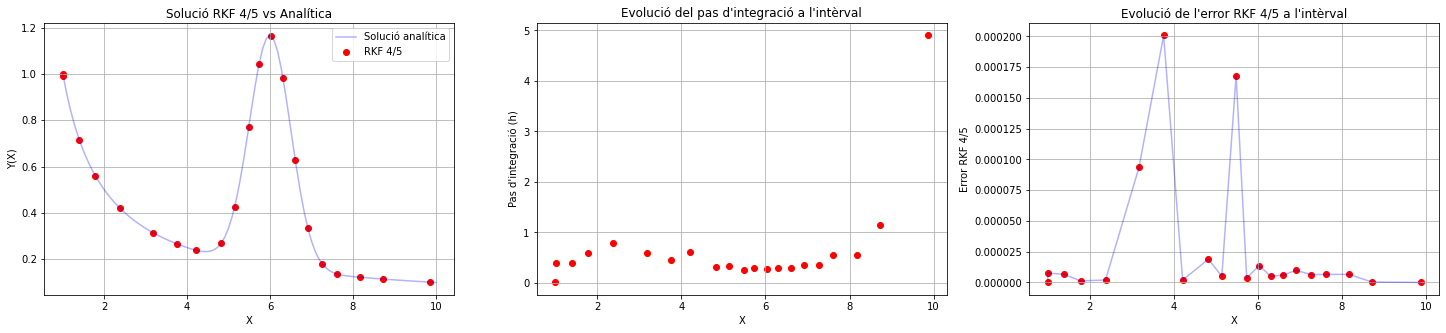

In [11]:
x0, xf, y0, h, tol, err = 1, 10, 1, 10e-3, 10e-6, 0
x, y, pas, error = [], [], [], []
#x0: posició inicial, xf: posició final, y0: condició inicial, h: pas d'integració, tol: error màxim, err: variable temporal per emmagatzemar errors
#Llistes --> x: valors de l'eix x, y: solucions numèriques, pas: emmagatzemar els nous pas d'integració, error: emmagatzemar els errors

def f(x,y):      #funció que retornarà f(x,y) de l'EDO donada
    return (-1/(x**2)) - 4*(x-6)*np.exp(-2*((x-6)**2)) 
def solucio(x):  #funció que retornarà la solució analítica de l'EDO
    return 1/x + np.exp(-2*((x-6)**2)) - np.exp(-50)


if FLAG == True:
    while x0 <= xf:
        
        x.append(x0); y.append(y0); pas.append(h); error.append(err)
        y_nou, h_nou, err = RKF1o(x0,y0,h,f)[0], RKF1o(x0,y0,h,f)[1], abs(RKF1o(x0,y0,h,f)[2])
        
        if h_nou <= h:
            h = h_nou
            del x[-1]; del y[-1]; del pas[-1]; del error[-1]
            continue
            
        y0 = y_nou; x0 = x0 + h; h = h_nou
    
    
    fig, ax = plt.subplots(ncols = 3, figsize = (25,5))  #Programa per graficar els resultats obtinguts
    ax[0].scatter(x, y, label = "RKF 4/5", c = "r")
    ax[0].plot(np.linspace(1,10,100), solucio(np.linspace(1,10,100)), c = "b", alpha = 0.3, label = "Solució analítica")
    ax[0].legend(); ax[0].grid(True)
    ax[0].set(xlabel = "X", ylabel = "Y(X)", title = "Solució RKF 4/5 vs Analítica")
    
    ax[1].scatter(x,pas, c = "r")
    ax[1].set(xlabel = "X", ylabel = "Pas d'integració (h)", title = "Evolució del pas d'integració a l'intèrval")
    ax[1].grid(True)
    
    ax[2].scatter(x,error, c = "r"); ax[2].plot(x,error, c = "b", alpha = 0.3); ax[2].grid(True)
    ax[2].set(xlabel = "X", ylabel = "Error RKF 4/5", title = "Evolució de l'error RKF 4/5 a l'intèrval")
    print("Nombre de punts necessitats:", len(x))  #Nombre de punts necessaris pel mètode RKF 4/5
    
else:
    while x0 <= xf:
        y0 = RKF1o(x0,y0,h,f); y.append(y0)
        x0 = x0 + h; x.append(x0)
    
    print("Nombre de punts necessitats:", len(x)) #Nombre de punts necessaris considerant un pas constant
    fig, ax = plt.subplots(figsize = (10,5))      #Programa per graficar els resultats obtinguts
    ax.scatter(x,y, s = 10, c = "r", label = "RKF (h constant)")
    ax.plot(np.linspace(1,10,100), solucio(np.linspace(1,10,100)), c = "black", label = "Solució analítica")
    ax.set(xlabel = "X", ylabel = "Y(X)", title = "Solució RKF 45 vs analítica (h=10e-3)")
    ax.grid(True); ax.legend()

### TASCA C)
Millorau el programa de la TASCA A per poder resoldre múltiples equacions i resoleu l'equació següent:

$$ \frac{d^2x}{dt^2}-\mu(1-x^2)\frac{dx}{dt}+x=0 $$

Sabent que l'EDO de 2on ordre és equivalent a dues de 1er ordre:

$$ \frac{dv}{dt} = \mu (1-x^2)v - x $$
$$ \frac{dx}{dt} = v $$

In [5]:
import matplotlib.pyplot as plt  #llibreria necessària
FLAG = True   #FLAG que activa el pas d'integració adaptatiu (FLAG = True), qualsevol altre valor de FLAG ho desactiva.

In [12]:
#Donades unes condicions inicials: t (temps = 0), x0 (posició inicial), v0 (velocitat inicial)
#Un pas d'integració h i dues funcions: vel i pos (Les dues funcions f obtingudes convertint l'EDO de 2on ordre en dues de 1er ordre)

#(ACTIVAR EL PROGRAMA)

def RKF2o(t, x0, v0, h, vel, pos):  #funció que realitza els càlculs de RKF 4/5
    f0v = vel(t, x0, v0)   #f0v,...,f5v: funcions intermitges del càlcul de RKF 4/5 per l'EDO corresponent a dv/dt
    f0p = pos(t, x0, v0)   #f0p,...,f5p: " "  "  " corresponent a dx/dt
    
    f1v = vel(t + h/4, x0 + (h/4)*f0p, v0 + (h/4)*f0v)
    f1p = pos(t + h/4, x0 + (h/4)*f0p, v0 + (h/4)*f0v)
    
    f2v = vel(t + (3*h/8), x0 + (3*h/32)*f0p + (9*h/32)*f1p, v0 + (3*h/32)*f0v + (9*h/32)*f1v)
    f2p = pos(t + (3*h/8), x0 + (3*h/32)*f0p + (9*h/32)*f1p, v0 + (3*h/32)*f0v + (9*h/32)*f1v)
    
    f3v = vel(t + (12*h/13), x0 + (1932*h/2197)*f0p - (7200*h/2197)*f1p + (7296*h/2197)*f2p, v0 + (1932*h/2197)*f0v - (7200*h/2197)*f1v + (7296*h/2197)*f2v)
    f3p = pos(t + (12*h/13), x0 + (1932*h/2197)*f0p - (7200*h/2197)*f1p + (7296*h/2197)*f2p, v0 + (1932*h/2197)*f0v - (7200*h/2197)*f1v + (7296*h/2197)*f2v)
    
    f4v = vel(t + h, x0 + (439*h/216)*f0p - 8*h*f1p + (3680*h/513)*f2p - (845*h/4104)*f3p, v0 + (439*h/216)*f0v -8*h*f1v + (3680*h/513)*f2v - (845*h/4104)*f3v)
    f4p = pos(t + h, x0 + (439*h/216)*f0p - 8*h*f1p + (3680*h/513)*f2p - (845*h/4104)*f3p, v0 + (439*h/216)*f0v -8*h*f1v + (3680*h/513)*f2v - (845*h/4104)*f3v)
    
    f5v = vel(t + h/2, x0 - (8*h/27)*f0p + 2*h*f1p - (3544*h/2565)*f2p + (1859*h/4104)*f3p - (11*h/40)*f4p, v0 - (8*h/27)*f0v + 2*h*f1v - (3544*h/2565)*f2v + (1859*h/4104)*f3v - (11*h/40)*f4v)
    f5p = pos(t + h/2, x0 - (8*h/27)*f0p + 2*h*f1p - (3544*h/2565)*f2p + (1859*h/4104)*f3p - (11*h/40)*f4p, v0 - (8*h/27)*f0v + 2*h*f1v - (3544*h/2565)*f2v + (1859*h/4104)*f3v - (11*h/40)*f4v)
    
    x_nou = x0 + h*((25/216)*f0p + (1408/2565)*f2p + (2197/4104)*f3p - (1/5)*f4p)  #Solució numèrica per la posició
    v_nou = v0 + h*((25/216)*f0v + (1408/2565)*f2v + (2197/4104)*f3v - (1/5)*f4v)  #Solució numèrica per la velocitat
    
    
    
    if FLAG == True:   #Si el pas d'integració adaptatiu està activat
        error_x = h*((1/360)*f0p - (128/4275)*f2p - (2197/75240)*f3p + (1/50)*f4p + (2/55)*f5p) #Error de la posició (comparat amb solució 5è ordre)
        error_v = h*((1/360)*f0v - (128/4275)*f2v - (2197/75240)*f3v + (1/50)*f4v + (2/55)*f5v) #Error de la velocitat (comparat amb solució 5è ordre)
    
        hx_nou = 0.9 * h * ((tol/abs(error_x))**(1/4))   #Nou pas d'integració per la posició 
        hv_nou = 0.9 * h * ((tol/abs(error_v))**(1/4))   #Nou pas d'integració per la velocitat
    
        h_nou = min(hx_nou, hv_nou)  #El pas més petit és l'utilitzat
        
        return x_nou, v_nou, h_nou  #Si el FLAG activat, la funció retorna un "tuple" amb solucions per x i v amb el nou pas d'integració
    else:
        return x_nou, v_nou #si el FLAG desactivat, la funció només retorna un "tuple" amb les solucions per x i v

In [13]:
if FLAG == True:  #Si FLAG activat
    while t <= tf:  #Bucle per iterar fins un temps desitjat
        
        x.append(x0); v.append(v0); temps.append(t); pas.append(h) #els últims resultats son emmagatzemats
        x_n, v_n, h_n = RKF2o(t, x0, v0, h, vel, pos)[0], RKF2o(t, x0, v0, h, vel, pos)[1], RKF2o(t, x0, v0, h, vel, pos)[2]
        #es crida a la funció RKF2o, assignant un nom a cada resultat de la "tuple" per comoditat
        
        if h_n <= h:  #Si h_nou es menor que la h inicial
            h = h_n   #El pas d'integració és substituit pel nou determinat 
            del x[-1]; del v[-1]; del temps[-1]; del pas[-1]  #Els últims valors registrats són esborrats
            continue  #Continue ens retorna al principi del bucle a la mateixa iteració.
        
        x0 = x_n; v0 = v_n; t = t + h; h = h_n  #Procès iteratiu: canviem els valors inicials de x i v pels nous obtinguts
        #Es realitza un pas en el temps i es canvia el pas d'integració pel nou determinat
        
else:  #Si FLAG no activat
    while t <= tf: #Bucle per iterar fins un temps desitjat
        
        x_n, v_n = RKF2o(t, x0, v0, h, vel, pos)[0], RKF2o(t, x0, v0, h, vel, pos)[1] #S'assigna un nom als resultats de la tuple per comoditat
        x.append(x_n); v.append(v_n)  #Els nous resultats solucions són emmagatzemats a llistes
        x0 = x_n; v0 = v_n   #Procés iteratiu: canviem els valors inicials de x i v pels nous obtinguts
        t = t + h; temps.append(t)  #Es realitza un pas en el temps i es emmagatzemat el nou temps
        
        
# NOTA: Aquest programa NO funciona sense les condicions inicials i paràmetres com h, tf i tolerància, només és el model utilitzat per la tasca c1 i c2
# per fer RKF 4/5 amb EDOs de segon ordre

NameError: name 't' is not defined

#### Tasca C1)
Emprant RKF i amb x(0)=2, v(0)=x'(0)=0 i μ=4. Representau x(t), v(t) i v vs x (diagrama de fases).

Nombre de punts necessitats per simular el primer minut:  566


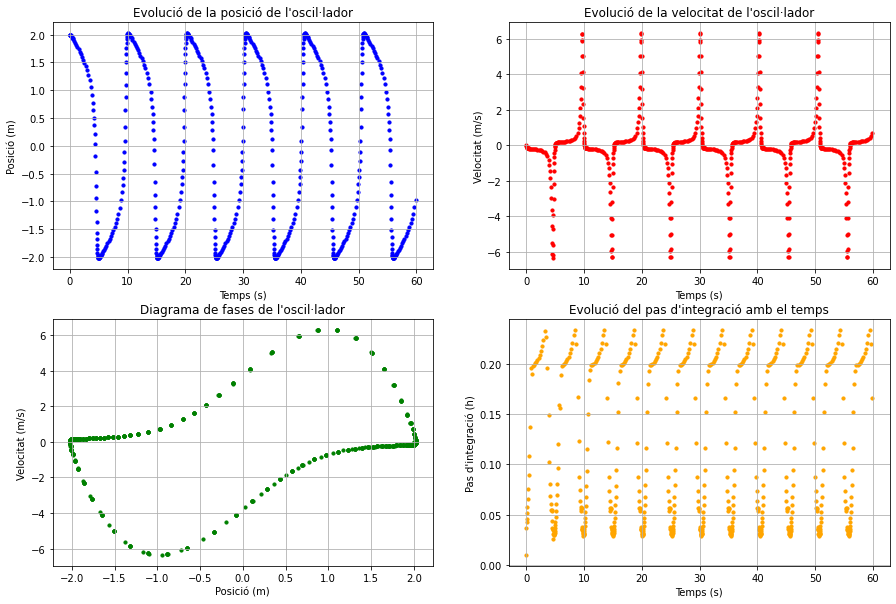

In [8]:
t, h, tf, x0, v0, mu, tol = 0, 10e-3, 60, 2, 0, 4, 10e-6
#t: temps inicial, h: pas d'integració inicial, tf: temps final, x0: posició inicial, v0: velocitat inicial
#mu: coeficient d'esmorteïment, tol: error màxim tolerat per la solució

FLAG = True

x, v, temps, pas = [], [], [], []  #llistes on seran emmagatzemats els resultats 
#x: llista per posicions, v: llista per velocitats, temps: llista per temps, pas: llista pels nous pasos d'integració

def vel(t, x, v):  #funció per dv/dt
    return mu*(1-x**2)*v - x

def pos(t, x, v):  #funció per dx/dt
    return v


if FLAG == True:
    while t <= tf:
        
        x.append(x0); v.append(v0); temps.append(t); pas.append(h)
        x_n, v_n, h_n = RKF2o(t, x0, v0, h, vel, pos)[0], RKF2o(t, x0, v0, h, vel, pos)[1], RKF2o(t, x0, v0, h, vel, pos)[2]
        
        if h_n <= h:
            h = h_n
            del x[-1]; del v[-1]; del temps[-1]; del pas[-1]
            continue
            
        x0 = x_n; v0 = v_n; t = t + h; h = h_n
        
    fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15,10))  #Programa per graficar els resultats obtinguts
    ax[0,0].scatter(temps, x, s = 10, c = "b"); ax[0,0].grid(True)
    ax[0,0].set(xlabel = "Temps (s)", ylabel = "Posició (m)", title = "Evolució de la posició de l'oscil·lador")
    
    ax[0,1].scatter(temps, v, s = 10, c = "r"); ax[0,1].grid(True)
    ax[0,1].set(xlabel = "Temps (s)", ylabel = "Velocitat (m/s)", title = "Evolució de la velocitat de l'oscil·lador")
    
    ax[1,0].scatter(x, v, s = 10, c = "g"); ax[1,0].grid(True)
    ax[1,0].set(xlabel = "Posició (m)", ylabel = "Velocitat (m/s)", title = "Diagrama de fases de l'oscil·lador")
    
    ax[1,1].scatter(temps, pas, s = 10, c = "orange"); ax[1,1].grid(True)
    ax[1,1].set(xlabel = "Temps (s)", ylabel = "Pas d'integració (h)", title = "Evolució del pas d'integració amb el temps")
    print("Nombre de punts necessitats per simular el primer minut: ", len(x)) #Nombre de punts necessitats

    
else:
    while t <= tf:
        
        x_n, v_n = RKF2o(t, x0, v0, h, vel, pos)[0], RKF2o(t, x0, v0, h, vel, pos)[1]
        x.append(x_n); v.append(v_n)
        x0 = x_n; v0 = v_n
        t = t + h; temps.append(t)
    
    print("Nombre de punts necessitats per simular el primer minut: ", len(x)) #Nombre de punts necessitats
    
    fig, ax = plt.subplots(ncols = 3, figsize = (20,5)) #Programa per graficar els resultats obtinguts
    ax[0].scatter(temps,x, s = 10, c = "b"); ax[0].grid(True)
    ax[0].set(xlabel = "Temps (s)", ylabel = "Posició (m)", title = "Evolució de la posició de l'oscil·lador")
    
    ax[1].scatter(temps,v, s = 10, c = "r"); ax[1].grid(True)
    ax[1].set(xlabel = "Temps (s)", ylabel = "Velocitat (m/s)", title = "Evolució de la velocitat de l'oscil·lador")
    
    ax[2].scatter(x,v, s = 10, c = "g"); ax[2].grid(True)
    ax[2].set(xlabel = "Posició (m)", ylabel = "Velocitat (m/s)", title = "Diagrama de fases de l'oscil·lador")

c2) Desactivau el control de pas de temps al programa RKF (deixant-la en un RK45) i resoleu l'equació per a x(0)=0.01, v(0)=0.01, μ=1 i un pas de temps Δt=0.5. Notau els avantatges de controlar la qualitat de la solució localment.

Nombre de punts necessitats per simular el primer minut:  121


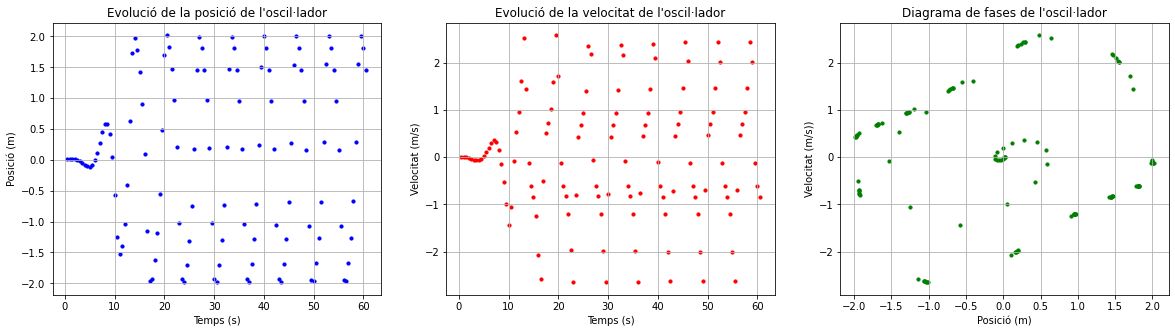

In [9]:
t, h, tf, x0, v0, mu, tol = 0, 0.5, 60, 0.01, 0.01, 1, 10e-6

x, v, temps, pas = [], [], [], []

FLAG = False

if FLAG == True:
    while t <= tf:
        
        x.append(x0); v.append(v0); temps.append(t); pas.append(h)
        x_n, v_n, h_n = RKF2o(t, x0, v0, h, vel, pos)[0], RKF2o(t, x0, v0, h, vel, pos)[1], RKF2o(t, x0, v0, h, vel, pos)[2]
        
        if h_n <= h:
            h = h_n
            del x[-1]; del v[-1]; del temps[-1]; del pas[-1]
            continue
            
        x0 = x_n; v0 = v_n; t = t + h; h = h_n
        
    fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15,10))
    ax[0,0].scatter(temps, x, s = 10, c = "b"); ax[0,0].grid(True)
    ax[0,0].set(xlabel = "Temps (s)", ylabel = "Posició (m)", title = "Evolució de la posició de l'oscil·lador")
    
    ax[0,1].scatter(temps, v, s = 10, c = "r"); ax[0,1].grid(True)
    ax[0,1].set(xlabel = "Temps (s)", ylabel = "Velocitat (m/s)", title = "Evolució de la velocitat de l'oscil·lador")
    
    ax[1,0].scatter(x, v, s = 10, c = "g"); ax[1,0].grid(True)
    ax[1,0].set(xlabel = "Posició (m)", ylabel = "Velocitat (m/s))", title = "Diagrama de fases de l'oscil·lador")
    
    ax[1,1].scatter(temps, pas, s = 10, c = "orange"); ax[1,1].grid(True)
    ax[1,1].set(xlabel = "Temps (s)", ylabel = "Pas d'integració (h)", title = "Evolució del pas d'integració amb el temps")
    
    print("Nombre de punts necessitats per simular el primer minut: ", len(x))

    
else:
    while t <= tf:
        
        x_n, v_n = RKF2o(t, x0, v0, h, vel, pos)[0], RKF2o(t, x0, v0, h, vel, pos)[1]
        x.append(x_n); v.append(v_n)
        x0 = x_n; v0 = v_n
        t = t + h; temps.append(t)
    
    print("Nombre de punts necessitats per simular el primer minut: ", len(x))
    fig, ax = plt.subplots(ncols = 3, figsize = (20,5))
    ax[0].scatter(temps,x, s = 10, c = "b"); ax[0].grid(True)
    ax[0].set(xlabel = "Temps (s)", ylabel = "Posició (m)", title = "Evolució de la posició de l'oscil·lador")
    
    ax[1].scatter(temps,v, s = 10, c = "r"); ax[1].grid(True)
    ax[1].set(xlabel = "Temps (s)", ylabel = "Velocitat (m/s)", title = "Evolució de la velocitat de l'oscil·lador")
    
    ax[2].scatter(x,v, s = 10, c = "g"); ax[2].grid(True)
    ax[2].set(xlabel = "Posició (m)", ylabel = "Velocitat (m/s))", title = "Diagrama de fases de l'oscil·lador")